In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import folium


print("Loading dataset...")

df = pd.read_csv("canadadataset.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
print(df.head())

numerical_columns = [
    'Forecasted 90th Percentile Best Yield',
    'Forecasted Median Yield',
    '% Departure from the Long Term (1987-last year) Mean Yield',
    '% Departure from the Last 5 Years (2019-2023) Mean Yield',
    '% Departure from Last Year\'s Mean Yield',
    'Bravis-Pearson Coefficients of Determination (R2)',
    'Root Mean Square Error',
    'LATITUDE',
    'LONGITUDE'
]

def preprocess_data(data, numerical_columns):

    print("Preprocessing data...")

    imputer = SimpleImputer(strategy='mean')
    imputed_data = imputer.fit_transform(data[numerical_columns])

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(imputed_data)

    return scaled_data


scaled_data = preprocess_data(df, numerical_columns)

def apply_pca(data, n_components=3):

    print("Applying PCA...")

    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(data)

    pca_df = pd.DataFrame(
        pca_result,
        columns=['PC1', 'PC2', 'PC3']
    )

    return pca_df, pca


pca_df, pca_model = apply_pca(scaled_data)

print("Explained Variance Ratio:")
print(pca_model.explained_variance_ratio_)

def apply_kmeans(pca_data, n_clusters=3):

    print("Applying KMeans Clustering...")

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    pca_data['Cluster'] = kmeans.fit_predict(pca_data)

    return pca_data, kmeans


pca_df, kmeans_model = apply_kmeans(pca_df)

df_model = df.copy()

df_model[['PC1', 'PC2', 'PC3']] = pca_df[['PC1', 'PC2', 'PC3']]

df_model['Cluster'] = pca_df['Cluster']

print("Cluster Counts:")
print(df_model['Cluster'].value_counts())

Loading dataset...
Dataset Shape: (1468, 17)
                                    PRNAME  CARUID    crop  forecastYear  \
0  British Columbia / Colombie-Britannique    5901  barley          2024   
1  British Columbia / Colombie-Britannique    5908  barley          2024   
2                                  Alberta    4830  barley          2024   
3                                  Alberta    4850  barley          2024   
4                                  Alberta    4870  barley          2024   

   forecastMonth  PR ID  Forecasted Median Yield  \
0              7     59                    59.45   
1              7     59                    54.86   
2              7     48                    75.29   
3              7     48                    77.70   
4              7     48                    68.21   

   Forecasted 10th Percentile Worst Yield  \
0                                   44.57   
1                                   43.32   
2                                   64.53   
3    


Generating 3D PCA Visualization...


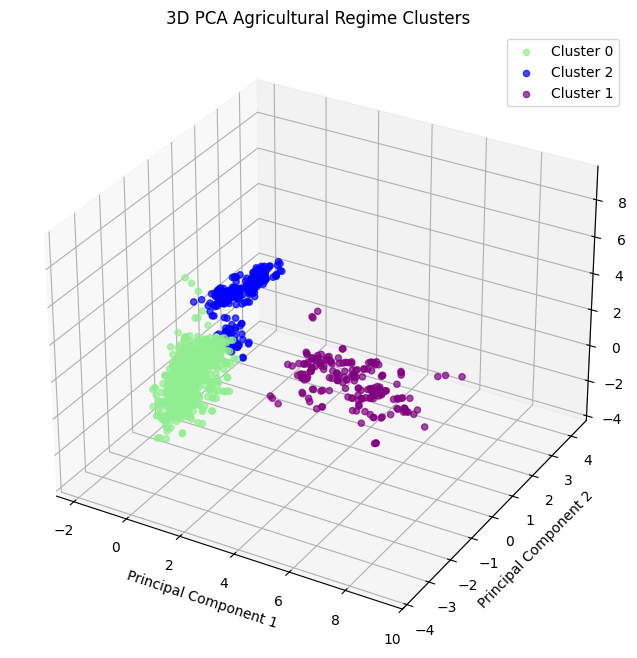


Generating Geographic Cluster Map...
Map generated successfully.


In [7]:
def plot_3d_clusters(pca_df):

    print("\nGenerating 3D PCA Visualization...")

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    colors = {
        0: 'lightgreen',
        1: 'purple',
        2: 'blue'
    }

    for cluster in pca_df['Cluster'].unique():

        subset = pca_df[pca_df['Cluster'] == cluster]

        ax.scatter(
            subset['PC1'],
            subset['PC2'],
            subset['PC3'],
            color=colors.get(cluster, 'black'),
            label=f'Cluster {cluster}',
            alpha=0.7
        )

    ax.set_title('3D PCA Agricultural Regime Clusters')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')

    ax.legend()

    plt.show()

plot_3d_clusters(pca_df)

def plot_cluster_map(df):

    print("\nGenerating Geographic Cluster Map...")

    canada_center = [56.1304, -106.3468]

    m = folium.Map(
        location=canada_center,
        zoom_start=4,
        tiles="cartodb positron"
    )

    cluster_colors = {
        0: 'lightgreen',
        1: 'purple',
        2: 'blue'
    }

    for _, row in df.iterrows():

        folium.CircleMarker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            radius=4,
            color=cluster_colors.get(row['Cluster'], 'black'),
            fill=True,
            fill_color=cluster_colors.get(row['Cluster'], 'black'),
            fill_opacity=0.8,
            popup=(
                f"Province: {row['PRNAME']}<br>"
                f"Crop: {row['crop']}<br>"
                f"Cluster: {row['Cluster']}"
            )
        ).add_to(m)

    print("Map generated successfully.")

    return m


cluster_map = plot_cluster_map(df_model)

cluster_map


CLUSTER PROFILE ANALYSIS
         Forecasted Median Yield  \
Cluster                            
0                      50.963622   
1                    1153.103915   
2                      69.403102   

         % Departure from the Long Term (1987-last year) Mean Yield  \
Cluster                                                               
0                                                25.092343            
1                                                13.606878            
2                                                 8.365793            

         % Departure from the Last 5 Years (2019-2023) Mean Yield  \
Cluster                                                             
0                                                 5.502447          
1                                                10.152432          
2                                                 1.337088          

         Root Mean Square Error   LATITUDE   LONGITUDE  
Cluster                            

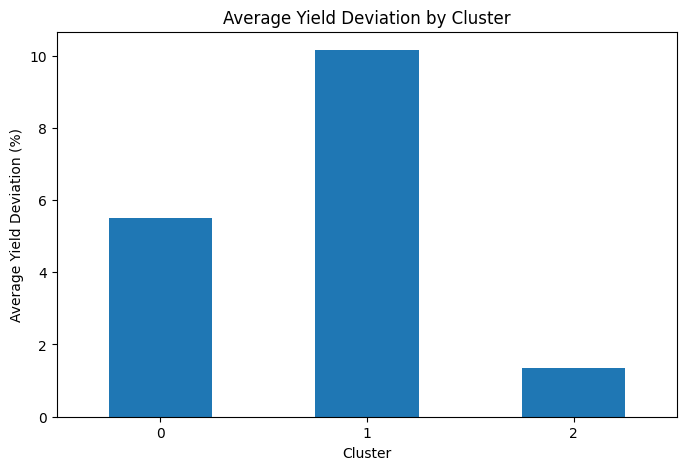


Crop Group Counts:
Crop_Group
Other Crops    1399
Lentils          69
Name: count, dtype: int64


In [8]:
def analyze_clusters(df):

    print("CLUSTER PROFILE ANALYSIS")

    cluster_summary = df.groupby('Cluster')[[
        'Forecasted Median Yield',
        '% Departure from the Long Term (1987-last year) Mean Yield',
        '% Departure from the Last 5 Years (2019-2023) Mean Yield',
        'Root Mean Square Error',
        'LATITUDE',
        'LONGITUDE'
    ]].mean()

    print(cluster_summary)

    return cluster_summary

cluster_summary = analyze_clusters(df_model)

def plot_yield_deviation_by_cluster(df):

    print("\nGenerating Yield Deviation Visualization...")

    deviation_means = df.groupby('Cluster')[
        '% Departure from the Last 5 Years (2019-2023) Mean Yield'
    ].mean()

    plt.figure(figsize=(8, 5))

    deviation_means.plot(kind='bar')

    plt.title('Average Yield Deviation by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Average Yield Deviation (%)')

    plt.xticks(rotation=0)
    plt.show()


plot_yield_deviation_by_cluster(df_model)

def assign_crop_group(crop_name):

    if str(crop_name).lower() == 'lentils':
        return 'Lentils'

    return 'Other Crops'


df_model['Crop_Group'] = df_model['crop'].apply(assign_crop_group)

print("\nCrop Group Counts:")
print(df_model['Crop_Group'].value_counts())




In [14]:
def train_cluster_models(df):

    results = []
    print("REGIME-SPECIFIC MODELING")

    for crop_group in df['Crop_Group'].unique():

        print(f"PROCESSING: {crop_group}")

        crop_data = df[df['Crop_Group'] == crop_group]

        for cluster in sorted(crop_data['Cluster'].unique()):

            print(f"\nProcessing Cluster {cluster}")

            cluster_data = crop_data[crop_data['Cluster'] == cluster]

            if len(cluster_data) < 10:
                print("Cluster too small. Skipping...")
                continue

            X = cluster_data[
                [
                    'LONGITUDE',
                    'LATITUDE',
                    'PC1',
                    'PC2',
                    'PC3'
                ]
            ]

            y = cluster_data['Forecasted Median Yield']

            # Preprocessing
            X = SimpleImputer(strategy='mean').fit_transform(X)
            X = StandardScaler().fit_transform(X)

            # Train/Test Split
            X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                test_size=0.2,
                random_state=42
            )

            # Model
            model = XGBRegressor(
                random_state=42,
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5
            )

            # Train
            model.fit(X_train, y_train)

            # Predict
            y_pred = model.predict(X_test)

            # Metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100

            # Units
            unit = 'lbs/ac' if crop_group == 'Lentils' else 'bu/ac'

            print(f"RMSE: {rmse:.4f} {unit}")
            print(f"MAPE: {mape:.4f}%")

            # Feature Importance
            importance_df = pd.DataFrame({
                'Feature': [
                    'LONGITUDE',
                    'LATITUDE',
                    'PC1',
                    'PC2',
                    'PC3'
                ],
                'Importance': model.feature_importances_
            }).sort_values(by='Importance', ascending=False)

            print("\nFeature Importance:")
            print(importance_df)

            # Store Results
            results.append({
                'Crop_Group': crop_group,
                'Cluster': cluster,
                'RMSE': rmse,
                'MAPE': mape,
                'Unit': unit
            })

    return pd.DataFrame(results)


cluster_results = train_cluster_models(df_model)

print("FINAL RESULTS")
print(cluster_results)

REGIME-SPECIFIC MODELING
PROCESSING: Other Crops

Processing Cluster 0
RMSE: 13.3220 bu/ac
MAPE: 20.9464%

Feature Importance:
     Feature  Importance
1   LATITUDE    0.276365
2        PC1    0.216276
0  LONGITUDE    0.201115
3        PC2    0.155606
4        PC3    0.150638

Processing Cluster 1
RMSE: 89.7768 bu/ac
MAPE: 7.8395%

Feature Importance:
     Feature  Importance
2        PC1    0.568384
0  LONGITUDE    0.189456
1   LATITUDE    0.105752
4        PC3    0.075512
3        PC2    0.060897

Processing Cluster 2
RMSE: 16.8340 bu/ac
MAPE: 23.4930%

Feature Importance:
     Feature  Importance
4        PC3    0.311272
1   LATITUDE    0.296001
2        PC1    0.256530
0  LONGITUDE    0.070138
3        PC2    0.066059
PROCESSING: Lentils

Processing Cluster 1
RMSE: 112.4029 lbs/ac
MAPE: 5.7285%

Feature Importance:
     Feature  Importance
2        PC1    0.652791
0  LONGITUDE    0.167443
1   LATITUDE    0.073806
4        PC3    0.064199
3        PC2    0.041761
FINAL RESULTS
    C